### Recurrently feed back later activations to earlier layers
This notebook tests a recurrent loop where a column from a GPT-2 MLP up-projection is fed through later layers and then recurrently cycled back, analyzing the resulting hidden states and decoded token predictions / logits gap at each step. The goal is to observe convergence / divergence behavior in the logit gap measure.

In [1]:
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer

sns.set_theme(style="whitegrid")

In [3]:
# Load GPT2 model
def get_partial_gpt2(model, start_layer=0, end_layer=12):
    """
    Load GPT2 model and return a modified version that only uses specified contiguous layers.
    
    Args:
        start_layer (int): Index of first layer to keep (inclusive)
        end_layer (int): Index of last layer to keep (exclusive)
    """    
    # Remove unused layers
    model = copy.deepcopy(model)
    model.transformer.h = torch.nn.ModuleList(
        model.transformer.h[start_layer:end_layer]
    )
    
    return model

# Example: Get GPT2 with only layers 3-7 (inclusive)
# partial_model = get_partial_gpt2(model, start_layer=3, end_layer=8)

In [4]:
model = AutoModelForCausalLM.from_pretrained('gpt2')
tokenizer = AutoTokenizer.from_pretrained('gpt2')

/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
def run_h_modules(model, residual_stream, start_layer=0, end_layer=12):
    """Run specified transformer layers on residual stream data.
    
    Args:
        model: GPT2 model
        residual_stream: Tensor of shape [batch, seq_len, hidden_dim]
        start_layer: First layer index to run (inclusive)
        end_layer: Last layer index to run (exclusive)
    """
    hidden_states = residual_stream
    for i in range(start_layer, end_layer):
        hidden_states = model.transformer.h[i](hidden_states)[0]
    return hidden_states

def run_h_modules_to_logits(model, residual_stream, start_layer=0, end_layer=12):
    """Run specified transformer layers and final layers to get token logits.
    
    Args:
        model: GPT2 model
        residual_stream: Tensor of shape [batch, seq_len, hidden_dim] 
        start_layer: First layer index to run (inclusive)
        end_layer: Last layer index to run (exclusive)
    """
    hidden_states = run_h_modules(model, residual_stream, start_layer, end_layer)
    hidden_states = model.transformer.ln_f(hidden_states)
    logits = model.lm_head(hidden_states)
    return logits

In [6]:
model.transformer.h[1].mlp.c_fc.weight.shape

torch.Size([768, 3072])

In [11]:
run_h_modules(model, torch.randn(1, 10, 768)).shape

"""
using run_h_modules and run_h_modules_to_logits make a function that starts with some particular column weight
in the up-projection FF matrix at layer n=3, then  passes it as first input through layers m=4,...,7
takes the output S of the layer 7 before its summation with the residual stream 
- passes it back into layer n=3 and does so in AR fashion for t=5 steps;
while also passing S to the tail of transformer and decoding the tokens (so that they are not used
in AR generation but are used as a sort of a window into what Transformer is thinking)
"""

def run_recurrent_loop(model, tokenizer,  layer_n=3, init_weight_column: int | list[int] | None=0, start_layer_m=4, end_layer_m=8, steps=5, topk=5):
    """
    Run a recurrent loop starting with a column from layer n's up-projection,
    passing through layers m, and feeding back to layer n.
    
    Args:
        model: GPT2 model
        layer_n: Layer to extract column from and feed back into (default 3)
        start_layer_m: First layer in middle sequence (default 4) 
        end_layer_m: Last layer in middle sequence (default 8)
        steps: Number of recurrent steps (default 5)
        
    Returns:
        Tuple containing:
        - List of input states at layer n
        - List of output states at layer m
        - List of top token probabilities and IDs for each step
    """
    # Get a column from the up-projection matrix of layer n
    up_proj = model.transformer.h[layer_n].mlp.c_fc.weight # [768, 3072]
    if init_weight_column is None:
        init_col = up_proj.unsqueeze(0).permute(2,0,1) # [3072, 1, 768]
    elif isinstance(init_weight_column, int):
        init_col = up_proj[:,init_weight_column].unsqueeze(0).unsqueeze(0) # [1, 1, 768]
    elif isinstance(init_weight_column, list):
        init_col = up_proj[:,init_weight_column].unsqueeze(0).unsqueeze(0) # [1, 1, 768]
    
    hidden_states = init_col
    
    # Store states and tokens
    layer_n_states = []
    layer_m_states = []
    token_outputs = []
    # Store previous logits for convergence check
    prev_logits = None
    logits_deltas = []
    
    for step in range(steps):
        # Run through layer n
        layer_n_out = model.transformer.h[layer_n](hidden_states)[0]
        layer_n_states.append(layer_n_out)
        
        # Run through layers m
        middle_out = run_h_modules(model, layer_n_out, 
                                 start_layer=start_layer_m,
                                 end_layer=end_layer_m)
        layer_m_states.append(middle_out)
        
        # Get logits for this step
        logits = run_h_modules_to_logits(model, middle_out, 
                                       start_layer=end_layer_m,
                                       end_layer=len(model.transformer.h))
        
        # Calculate L2 distance between current and previous logits
        if prev_logits is not None:
            # Calculate L2 norm along vocab dimension while preserving batch dimension
            delta = torch.norm(logits - prev_logits, dim=-1).detach()  # [batch_size, seq_len]
            logits_deltas.append(delta)
        prev_logits = logits.detach().clone()
        
        # Get top tokens
        probs = torch.nn.functional.softmax(logits[0,-1], dim=-1)
        top_tokens = torch.topk(probs, k=topk)
        token_outputs.append((top_tokens.values, top_tokens.indices))
            
        # Feed middle_out back as input for next step
        hidden_states = middle_out
    
    layer_n_states = torch.concat(layer_n_states, dim=1)
    layer_m_states = torch.concat(layer_m_states, dim=1)
    logits_deltas = torch.concat(logits_deltas, dim=1)
    return layer_n_states, layer_m_states, token_outputs, logits_deltas


In [17]:
logits_deltas[0].shape, len(decoded_top_tokens)

(torch.Size([11]), 12)

In [23]:
logits_deltas[0].tolist()

[5248.42236328125,
 3377.8359375,
 2639.75,
 1837.84375,
 1318.136474609375,
 980.3890991210938,
 790.6979370117188,
 669.0107421875,
 574.0715942382812,
 496.224853515625,
 432.4160461425781]

In [27]:
range(len(logits_deltas[0]))

range(0, 11)

In [30]:
range(len(logits_deltas[0])-1), len(logits_deltas[0].tolist())

(range(0, 10), 11)

/var/folders/pp/39s43hbj13x0szy5481vm3x00000gn/T/ipykernel_3997/2545417264.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(decoded_top_tokens)


[Text(-2.0, 0, '-'),
 Text(0.0, 0, '-'),
 Text(2.0, 0, '-'),
 Text(4.0, 0, 'etc'),
 Text(6.0, 0, 'etc'),
 Text(8.0, 0, 'including'),
 Text(10.0, 0, 'including'),
 Text(12.0, 0, 'including')]

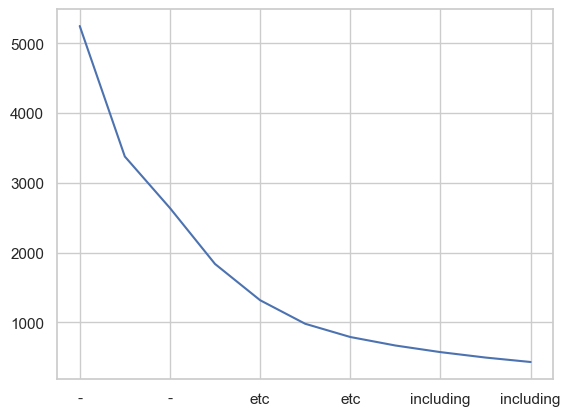

In [31]:
layer_n_states, layer_m_states, token_outputs, logits_deltas = run_recurrent_loop(model, tokenizer,
                                                                    layer_n=4, 
                                                                    init_weight_column=333,
                                                                    start_layer_m=5,
                                                                    end_layer_m=10,
                                                                    steps=12,
                                                                    topk=5)
# token_outputs [step, (top_k_probs, top_k_indices)]
# tokenizer.decode([token_outputs[s][1][0] for s in range(len(token_outputs))])
decoded_top_tokens = [tokenizer.decode(token_outputs[s][1][0]).strip() for s in range(len(token_outputs))]
 
plt.figure()
ax = sns.lineplot(x=range(len(logits_deltas[0])), y=logits_deltas[0].tolist())
ax.set_xticklabels(decoded_top_tokens)

In [75]:
layer_n_states, layer_m_states, token_outputs, logits_deltas = run_recurrent_loop(model, tokenizer,
                                                                    layer_n=4, 
                                                                    init_weight_column=torch.arange(1000),
                                                                    start_layer_m=5,
                                                                    end_layer_m=10,
                                                                    steps=12,
                                                                    topk=5)

In [82]:
logits_deltas

[416387.71875,
 175052.984375,
 152998.21875,
 134325.671875,
 115841.0546875,
 99172.53125,
 84847.609375,
 72479.9609375,
 62516.00390625,
 53935.203125,
 46979.52734375]